# Flow Past a Cylinder - 2D Incompressible Navier-Stokes

A finite-difference solver for channel flow past a circular cylinder, the
canonical CFD benchmark for **vortex shedding** (the *Karman vortex street*).

This notebook does two things:

1. **Re_D = 25** - a low-Reynolds run that settles into a *steady, symmetric*
   wake (a pair of standing recirculation vortices behind the cylinder).
2. **Re_D = 100** - a higher-Reynolds run that becomes *unstable* and sheds a
   periodic train of alternating vortices, which we animate and validate by
   measuring the **Strouhal number** (expected $St \approx 0.2$).

### Method
- Projection (Chorin-style) time stepping: solve a pressure-Poisson equation
  each step, then correct the velocity toward $\nabla\cdot\mathbf u = 0$.
- **Central differences** for the convective terms. This matters: first-order
  upwind adds numerical diffusion $\sim u\,\Delta x/2$, which on a tractable
  grid drags the *effective* Reynolds number so low that shedding is
  suppressed entirely. Central differencing has ~zero numerical diffusion, so
  the instability survives.
- The cylinder is imposed as an **immersed solid**: velocity is zeroed inside a
  circular mask after each update. (Simple and robust; surface forces would
  need a sharper boundary treatment.)


## 1. Imports

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, animation
from IPython.display import HTML
from numba import njit, prange

## 2. Grid and physical parameters

The domain is a channel of length `Lx` by height `Ly`, with the cylinder placed
a couple of diameters from the inlet. The cylinder Reynolds number is

$$Re_D = \frac{U_\infty\,D}{\nu}.$$

Two stability limits set the time step for this explicit scheme:

- **Convective (CFL):** $\Delta t \lesssim \Delta x / U_\infty$
- **Diffusive:** $\Delta t \lesssim \left[2\nu\left(\Delta x^{-2}+\Delta y^{-2}\right)\right]^{-1}$

The helper below reports both so you can see the chosen `dt` is safely under them.

In [16]:
def make_grid(nx, ny, Lx, Ly, D, x_c=2.0):
    dx, dy = Lx/(nx-1), Ly/(ny-1)
    x = np.linspace(0, Lx, nx)
    y = np.linspace(0, Ly, ny)
    X, Y = np.meshgrid(x, y)
    R = D/2
    y_c = Ly/2
    mask = (X - x_c)**2 + (Y - y_c)**2 <= R**2   # True inside the cylinder
    return dict(nx=nx, ny=ny, Lx=Lx, Ly=Ly, dx=dx, dy=dy,
                x=x, y=y, X=X, Y=Y, D=D, R=R, x_c=x_c, y_c=y_c, mask=mask)

def report_stability(g, nu, dt, U_inf=1.0):
    dx, dy = g['dx'], g['dy']
    conv = dx/U_inf
    diff = 1/(2*nu*(1/dx**2 + 1/dy**2))
    print(f"Re_D = {U_inf*g['D']/nu:.0f}")
    print(f"dx={dx:.4f}  dy={dy:.4f}")
    print(f"CFL: dt={dt} vs convective limit {conv:.4f}  -> {'OK' if dt<conv else 'TOO BIG'}")
    print(f"     dt={dt} vs diffusive  limit {diff:.4f}  -> {'OK' if dt<diff else 'TOO BIG'}")

## 3. Discrete operators

**Pressure source term** - take the divergence of the momentum equation and
enforce incompressibility:

$$b = \rho\left[\frac{1}{\Delta t}\Big(\tfrac{\partial u}{\partial x}+\tfrac{\partial v}{\partial y}\Big)
- \Big(\tfrac{\partial u}{\partial x}\Big)^2 - 2\tfrac{\partial u}{\partial y}\tfrac{\partial v}{\partial x}
- \Big(\tfrac{\partial v}{\partial y}\Big)^2\right].$$

The $\tfrac{1}{\Delta t}\nabla\cdot\mathbf u$ part measures how far the current
velocity field is from being divergence-free; feeding it into the Poisson solve
is what pulls the velocity back toward incompressibility each step.

**Convection** uses central differences (see the note in the intro).

In [17]:
def conv(a, f, axis, dx, dy):
    """a * df/d(axis), 2nd-order central. Zero numerical diffusion -> shedding survives."""
    ai = a[1:-1, 1:-1]
    if axis == 1:   # d/dx
        return ai * (f[1:-1, 2:] - f[1:-1, 0:-2]) / (2*dx)
    else:           # d/dy
        return ai * (f[2:, 1:-1] - f[0:-2, 1:-1]) / (2*dy)

def laplacian(f, dx, dy):
    return ((f[1:-1, 2:] - 2*f[1:-1, 1:-1] + f[1:-1, 0:-2]) / dx**2 +
            (f[2:, 1:-1] - 2*f[1:-1, 1:-1] + f[0:-2, 1:-1]) / dy**2)

def build_b(u, v, rho, dt, dx, dy):
    b = np.zeros_like(u)
    dudx = (u[1:-1, 2:] - u[1:-1, 0:-2]) / (2*dx)
    dvdy = (v[2:, 1:-1] - v[0:-2, 1:-1]) / (2*dy)
    dudy = (u[2:, 1:-1] - u[0:-2, 1:-1]) / (2*dy)
    dvdx = (v[1:-1, 2:] - v[1:-1, 0:-2]) / (2*dx)
    b[1:-1, 1:-1] = rho*((dudx + dvdy)/dt - dudx**2 - 2*dudy*dvdx - dvdy**2)
    return b

@njit(fastmath=True, parallel=True)
def pressure_poisson(p, b, dx, dy, nit=50):
    """Jacobi/Gauss-Seidel relaxation of  d2p/dx2 + d2p/dy2 = b.
    BCs: p=0 at outlet (reference), zero-gradient on inlet and both walls."""
    ny, nx = p.shape
    dx2 = dx * dy
    dy2 = dy * dx
    denom = 2.0 * (dx2 + dy2)
    inv_denom = 1.0 / denom
    coeff = (dx2 * dy2) * inv_denom
    
    for _ in range(nit):
        pn = p.copy()
        for j in prange (1, ny - 1):
            for i in range(1, nx -1):
                p[j,i] = (((p[j, i + 1] + p[j, i - 1]) * dy2 +
                           (p[j + 1, i] + p[j - 1, i]) * dx2) * inv_denom) - (coeff * b[j, i])
        for j in range(ny):
            p[j, -1] = 0.0
            p[j, 0] = p[j, 1]

        for i in range(nx):
            p[0, i] = p[1, i]
            p[-1, i] = p[-2, i]
        
    return p

## 4. The solver

Each time step:

1. Build the pressure source `b` from the current velocity.
2. Relax the pressure-Poisson equation for `p`.
3. Advance `u`, `v` with the momentum equation (convection + pressure gradient
   + viscous diffusion).
4. Apply boundary conditions and re-impose the solid cylinder.

**Boundary conditions**

| Boundary | Condition |
|---|---|
| Inlet (left) | $u=U_\infty,\ v=0$ |
| Outlet (right) | zero-gradient (flow exits freely) |
| Top & bottom walls | no-slip $u=v=0$ |
| Cylinder | no-slip (immersed mask) |

A brief, small asymmetric `v`-jolt just behind the cylinder during the first
half time-unit **seeds** the instability. A perfectly symmetric setup will not
shed even above the critical Reynolds number, because there is nothing to break
the symmetry - the perturbation is the physical trigger.

The optional `probe` records the transverse velocity `v` at a point in the wake
so we can measure the shedding frequency later.

In [18]:
def simulate(g, nu, dt, nsteps, rho=1.0, U_inf=1.0, nit=50,
             save_every=25, trigger=True, verbose=True):
    ny, nx = g['ny'], g['nx']
    dx, dy = g['dx'], g['dy']
    mask = g['mask']

    u = np.full((ny, nx), U_inf); v = np.zeros((ny, nx)); p = np.zeros((ny, nx))
    u[mask] = 0.0; v[mask] = 0.0

    # wake probe: ~1.5 diameters downstream, slightly off-axis to catch asymmetry
    pi = int((g['x_c'] + 1.5*g['D']) / dx)
    pj = int((g['y_c'] + 0.1) / dy)

    frames, frame_t, probe_v = [], [], []

    for s in range(nsteps):
        un, vn = u.copy(), v.copy()
        b = build_b(u, v, rho, dt, dx, dy)
        p = pressure_poisson(p, b, dx, dy, nit)

        u[1:-1, 1:-1] = (un[1:-1, 1:-1]
            - dt*conv(un, un, 1, dx, dy) - dt*conv(vn, un, 0, dx, dy)
            - dt/(2*rho*dx)*(p[1:-1, 2:] - p[1:-1, 0:-2])
            + nu*dt*laplacian(un, dx, dy))
        v[1:-1, 1:-1] = (vn[1:-1, 1:-1]
            - dt*conv(un, vn, 1, dx, dy) - dt*conv(vn, vn, 0, dx, dy)
            - dt/(2*rho*dy)*(p[2:, 1:-1] - p[0:-2, 1:-1])
            + nu*dt*laplacian(vn, dx, dy))

        # boundary conditions
        u[:, 0] = U_inf; v[:, 0] = 0.0            # inlet
        u[:, -1] = u[:, -2]; v[:, -1] = v[:, -2]  # outlet (zero-gradient)
        u[0, :] = 0.0; v[0, :] = 0.0              # bottom wall
        u[-1, :] = 0.0; v[-1, :] = 0.0            # top wall
        u[mask] = 0.0; v[mask] = 0.0              # cylinder

        if trigger and s*dt < 0.5:                # seed the instability
            v[pj, pi] += 0.05

        if not np.isfinite(u).all():
            raise FloatingPointError(f"diverged at step {s}")

        probe_v.append(v[pj, pi])
        if s % save_every == 0:
            w = np.zeros((ny, nx))               # vorticity for plotting
            w[1:-1, 1:-1] = ((v[1:-1, 2:] - v[1:-1, 0:-2])/(2*dx)
                             - (u[2:, 1:-1] - u[0:-2, 1:-1])/(2*dy))
            w[mask] = np.nan
            frames.append(w.copy()); frame_t.append(s*dt)
        if verbose and s % 1000 == 0:
            print(f"step {s:5d}  t={s*dt:5.2f}  max|u|={np.max(np.abs(u)):.3f}  "
                  f"probe_v={v[pj,pi]:+.4f}")

    return dict(u=u, v=v, p=p,
                frames=np.array(frames), frame_t=np.array(frame_t),
                probe_v=np.array(probe_v), dt=dt)

## 5. Run 1 - Re_D = 25: steady symmetric wake

At low Reynolds number the wake is **steady**: two symmetric recirculation
vortices sit glued behind the cylinder. There is *no* shedding below
$Re_D \approx 47$, so this is the physically correct result - a good sanity
check before chasing the vortex street.

In [19]:
g25 = make_grid(nx=161, ny=41, Lx=8.0, Ly=2.0, D=0.5)
report_stability(g25, nu=0.02, dt=0.0005)
sol25 = simulate(g25, nu=0.02, dt=0.0005, nsteps=3500, save_every=100, trigger=False)

# check for a recirculation bubble: negative u on the wake centerline
j = g25['ny']//2
i0 = int((g25['x_c'] + g25['R'])/g25['dx']); i1 = int((g25['x_c'] + 2.0)/g25['dx'])
print("min wake-centerline u (negative => recirculation):",
      round(sol25['u'][j, i0:i1].min(), 4))

Re_D = 25
dx=0.0500  dy=0.0500
CFL: dt=0.0005 vs convective limit 0.0500  -> OK
     dt=0.0005 vs diffusive  limit 0.0313  -> OK
step     0  t= 0.00  max|u|=1.312  probe_v=-0.0047
step  1000  t= 0.50  max|u|=1.788  probe_v=-0.1665
step  2000  t= 1.00  max|u|=1.814  probe_v=-0.1568
step  3000  t= 1.50  max|u|=1.829  probe_v=-0.0666
min wake-centerline u (negative => recirculation): -0.1016


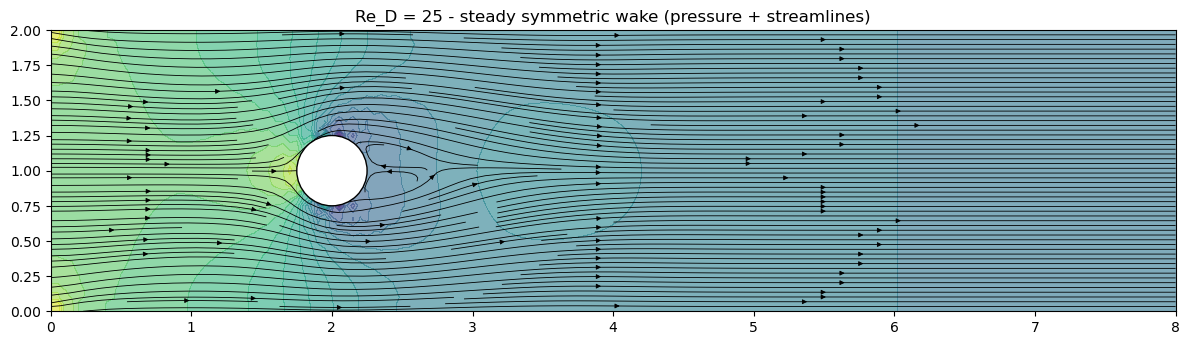

In [20]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.contourf(g25['X'], g25['Y'], sol25['p'], levels=30, alpha=0.6, cmap=cm.viridis)
ax.streamplot(g25['X'], g25['Y'], sol25['u'], sol25['v'],
              color='k', density=2.0, linewidth=0.6, arrowsize=0.7)
ax.add_patch(plt.Circle((g25['x_c'], g25['y_c']), g25['R'], color='white', ec='k', zorder=5))
ax.set_aspect('equal'); ax.set_xlim(0, g25['Lx']); ax.set_ylim(0, g25['Ly'])
ax.set_title('Re_D = 25 - steady symmetric wake (pressure + streamlines)')
plt.tight_layout()

## 6. Run 2 - Re_D = 100: the Karman vortex street

Now we raise the Reynolds number (finer grid, lower viscosity). Above the
critical $Re_D \approx 47$ the steady wake is **unstable**: the trigger
perturbation grows into a self-sustained oscillation, shedding alternating
vortices. This run is heavier but since we use numba, it'll be about a minute (with pure numpy it would be a few minutes).

In [21]:
g100 = make_grid(nx=401, ny=101, Lx=8.0, Ly=2.0, D=0.4)
report_stability(g100, nu=0.004, dt=0.002)
sol100 = simulate(g100, nu=0.004, dt=0.002, nsteps=8000, save_every=25, trigger=True)

Re_D = 100
dx=0.0200  dy=0.0200
CFL: dt=0.002 vs convective limit 0.0200  -> OK
     dt=0.002 vs diffusive  limit 0.0250  -> OK
step     0  t= 0.00  max|u|=1.217  probe_v=+0.0498
step  1000  t= 2.00  max|u|=1.571  probe_v=-0.0052
step  2000  t= 4.00  max|u|=1.551  probe_v=+0.0245
step  3000  t= 6.00  max|u|=1.549  probe_v=+0.0149
step  4000  t= 8.00  max|u|=1.554  probe_v=+0.0261
step  5000  t=10.00  max|u|=1.564  probe_v=+0.0530
step  6000  t=12.00  max|u|=1.587  probe_v=+0.0781
step  7000  t=14.00  max|u|=1.671  probe_v=-0.0216


## 7. Validation - the Strouhal number

The dimensionless shedding frequency is the **Strouhal number**

$$St = \frac{f\,D}{U_\infty},$$

where $f$ is the shedding frequency. For a cylinder wake in this Reynolds
range the experimental value is $St \approx 0.2$. We recover $f$ from the
wake-probe signal two independent ways - counting zero-crossings and an FFT -
and they should agree near 0.2, confirming the physics (not just that
*something* oscillates, but that it oscillates at the *right* frequency).

In [ ]:
def strouhal(sol, D, U_inf=1.0):
    pv = sol['probe_v']; dt = sol['dt']
    tail = pv[len(pv)//3:]                     # drop startup transient
    s = tail - tail.mean()
    zc = np.where(np.diff(np.sign(s)))[0]
    out = {}
    if len(zc) >= 4:
        T = 2*np.mean(np.diff(zc))*dt
        out['St_zerocross'] = D/(T*U_inf)
    sp = np.abs(np.fft.rfft(s)); fr = np.fft.rfftfreq(len(s), dt)
    k = 1 + int(np.argmax(sp[1:]))
    out['St_fft'] = fr[k]*D/U_inf
    out['sheds'] = tail.std() > 0.02 and len(zc) >= 4
    return out

res = strouhal(sol100, g100['D'])
print("shedding detected:", res['sheds'])
print("St (zero-crossing): %.3f" % res.get('St_zerocross', float('nan')))
print("St (FFT):           %.3f" % res['St_fft'])
print("expected:           ~0.20")

fig, ax = plt.subplots(figsize=(10, 3), dpi=100)
t = np.arange(len(sol100['probe_v']))*sol100['dt']
ax.plot(t, sol100['probe_v'], 'C3', lw=1)
ax.set_xlabel('time'); ax.set_ylabel('v at wake probe')
ax.set_title('Wake probe: transient growth -> self-sustained shedding')
plt.tight_layout()

## 8. Animation - the vortex street

Vorticity field over time. Red and blue are opposite-sign vortices; watch them
peel off the cylinder alternately and organize into the staggered double row
that defines the Karman vortex street.

In [ ]:
frames, ft = sol100['frames'], sol100['frame_t']
vmax = np.percentile(np.abs(frames[np.isfinite(frames)]), 98)

fig, ax = plt.subplots(figsize=(11, 3.2), dpi=100)
def draw(k):
    ax.clear()
    ax.contourf(g100['X'], g100['Y'], frames[k],
                levels=np.linspace(-vmax, vmax, 41), cmap=cm.RdBu_r, extend='both')
    ax.add_patch(plt.Circle((g100['x_c'], g100['y_c']), g100['R'], color='0.2', zorder=5))
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'Vorticity - Re_D=100   t={ft[k]:.2f}')

anim = animation.FuncAnimation(fig, draw, frames=len(frames), interval=60)
plt.close(fig)
HTML(anim.to_jshtml())

In [ ]:
# Optional: save the animation to disk
# anim.save('vortex_street.gif', writer=animation.PillowWriter(fps=18))

## Notes & caveats

- **Why central differencing?** First-order upwind is stable and simple but adds
  numerical diffusion $\sim U\,\Delta x/2$. At these grid sizes that swamps the
  real viscosity and pushes the *effective* Reynolds number well below critical,
  so the wake never sheds. Central differencing removes that artificial
  viscosity; the mild cell-Peclet wiggles it can introduce are kept in check by
  the real viscosity and a small `dt`.
- **Immersed cylinder.** Zeroing velocity inside a circular mask is a crude
  ("staircased") boundary. It is robust and fine for visualizing the wake, but
  surface quantities like drag/lift coefficients would need a sharper immersed-
  boundary or body-fitted mesh for quantitative accuracy.
- **Explicit scheme.** Keep `dt` under both stability limits printed by
  `report_stability`. If you lower `nu` (raise Re) further, shrink `dt` and
  refine the grid accordingly.